In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
#Verifying GPU Availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
#CNN's need tensor inputs, not as PILLOW images, thus they need to be converted using ToTensor.
#The tensors are then changed from [0,255] to [0,1] to make it easier to normalize.
transform = transforms.Compose([
    transforms.ToTensor(),
])

#Fashion MNIST Training Data
Fashion_mnist_train_validation = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
Fashion_mnist_train , Fashion_mnist_validate  = random_split(
    Fashion_mnist_train_validation, [50000, 10000], generator=torch.Generator().manual_seed(1)
)

#Fashion MNIST Testing Data
Fashion_mnist_test = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

#DataLoader divides the dataset into mini-batches.
#shuffle randomizes the chosen sets.
Fashion_mnist_train_loader = DataLoader(
    Fashion_mnist_train,
    batch_size=512,
    num_workers=2,   
    pin_memory=True,
    shuffle=True
)
Fashion_mnist_validate_loader = DataLoader(
    Fashion_mnist_validate,
    batch_size=512,
    num_workers=2,   
    pin_memory=True,
    shuffle=False
)
Fashion_mnist_test_loader = DataLoader(
    Fashion_mnist_test,
    batch_size=512,
    num_workers=2,   
    pin_memory=True,
    shuffle=False
)

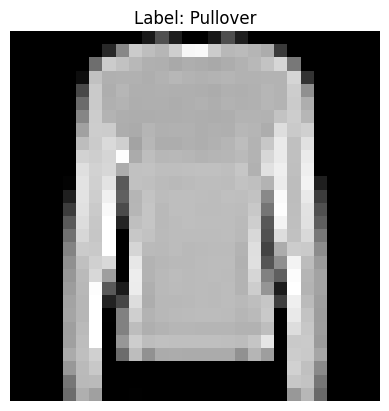

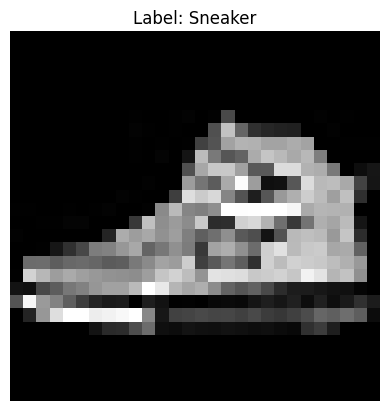

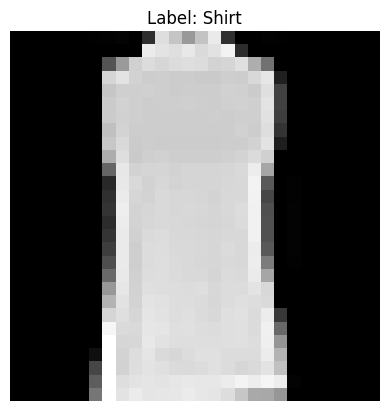

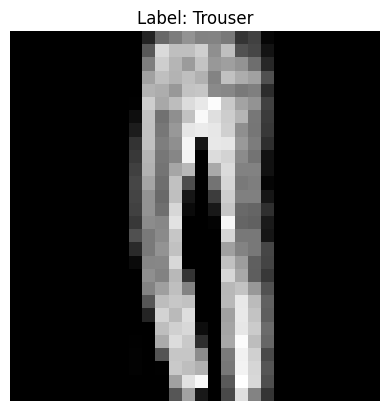

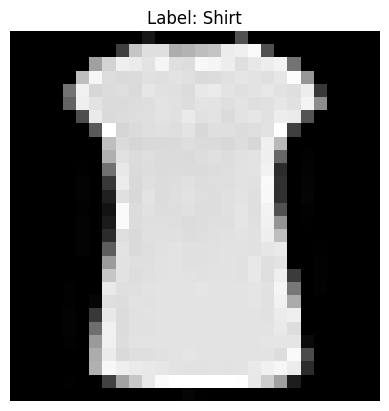

In [4]:
#Defining the Classes
class_names =["T-shirt/top","Trouser", "Pullover","Dress","Coat", "Sandal","Shirt","Sneaker","Bag", "Ankle boot"]

#Verification of dataset


for i in range(5):
  image,label=Fashion_mnist_train[i]
  plt.figure()
  # Squeeze or rearrange dimensions because PyTorch uses [Channels, Height, Width]
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f"Label: {class_names[label]}")
  plt.axis('off')
  plt.show()

In [ ]:
#Model
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel,self).__init__()
        # Input Layer as per given model
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 16)
        self.left_fc1 = nn.Linear(16, 8)
        self.left_fc2 = nn.Linear(8, 8)
        self.right_fc1 = nn.Linear(16, 12)
        self.right_fc2 = nn.Linear(12, 8)
        self.output = nn.Linear(16, 10)

    def forward(self,x):
        x=self.flatten(x)
        x=F.relu(self.fc1(x))
        left=F.relu(self.left_fc1(x))
        skip=left
        left=F.relu(self.left_fc2(left))
        left=left+skip
        right=F.relu(self.right_fc1(x))
        right=F.relu(self.right_fc2(right))
        merged=torch.cat((left,right),dim=1)
        output=self.output(merged)
        return output

In [6]:
model = MyModel().to(device)

#Standard loss function
loss = nn.CrossEntropyLoss()

#Adam automatically changes the learning rate dependent on whats best
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

epochs = 100
batch_size = 2048 

all_train_images = Fashion_mnist_train.dataset.data[Fashion_mnist_train.indices].float().unsqueeze(1).to(device) / 255.0
all_train_labels = Fashion_mnist_train.dataset.targets[Fashion_mnist_train.indices].to(device)

all_val_images = Fashion_mnist_validate.dataset.data[Fashion_mnist_validate.indices].float().unsqueeze(1).to(device) / 255.0
all_val_labels = Fashion_mnist_validate.dataset.targets[Fashion_mnist_validate.indices].to(device)

for epoch in range(epochs):
    model.train()
    running_loss = 0
    num_batches = 0

    for i in range(0, len(all_train_images), batch_size):
        images = all_train_images[i:i+batch_size]
        labels = all_train_labels[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = model(images)
        losses = loss(outputs, labels)

        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        num_batches += 1

    epoch_loss = running_loss / num_batches
    train_losses.append(epoch_loss)
    
    # Validation Phase
    model.eval()
    with torch.no_grad():
        outputs = model(all_val_images)
        current_loss = loss(outputs, all_val_labels)
        
        epoch_val_loss = current_loss.item()
        _, predicted = torch.max(outputs, 1)
        
        correct = (predicted == all_val_labels).sum().item()
        val_accuracy = 100 * correct / len(all_val_labels)

    #  Save validation metrics for plotting
    val_losses.append(epoch_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] -> "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/100] -> Train Loss: 2.1273 | Val Loss: 1.8953 | Val Acc: 42.28%
Epoch [2/100] -> Train Loss: 1.6252 | Val Loss: 1.3371 | Val Acc: 56.85%
Epoch [3/100] -> Train Loss: 1.1522 | Val Loss: 0.9833 | Val Acc: 64.04%
Epoch [4/100] -> Train Loss: 0.8929 | Val Loss: 0.8034 | Val Acc: 71.04%
Epoch [5/100] -> Train Loss: 0.7527 | Val Loss: 0.6984 | Val Acc: 75.46%
Epoch [6/100] -> Train Loss: 0.6655 | Val Loss: 0.6311 | Val Acc: 78.02%
Epoch [7/100] -> Train Loss: 0.6082 | Val Loss: 0.5859 | Val Acc: 79.81%
Epoch [8/100] -> Train Loss: 0.5687 | Val Loss: 0.5554 | Val Acc: 80.82%
Epoch [9/100] -> Train Loss: 0.5406 | Val Loss: 0.5342 | Val Acc: 81.65%
Epoch [10/100] -> Train Loss: 0.5201 | Val Loss: 0.5177 | Val Acc: 82.33%
Epoch [11/100] -> Train Loss: 0.5038 | Val Loss: 0.5036 | Val Acc: 82.78%
Epoch [12/100] -> Train Loss: 0.4899 | Val Loss: 0.4925 | Val Acc: 83.14%
Epoch [13/100] -> Train Loss: 0.4788 | Val Loss: 0.4840 | Val Acc: 83.47%
Epoch [14/100] -> Train Loss: 0.4698 | Val Loss

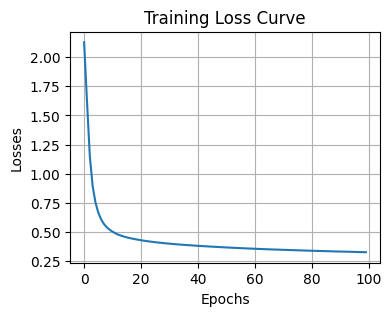

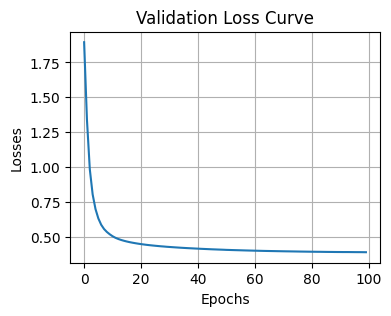

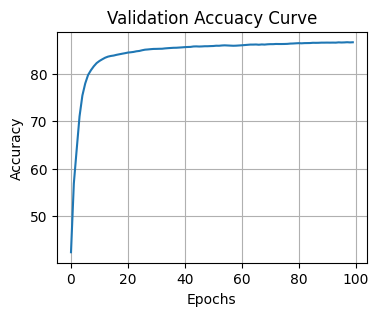

In [8]:
#Training LOSS CURVE
plt.figure(figsize=(4,3))
plt.title("Training Loss Curve")
plt.plot(train_losses)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.grid()
plt.show()

#Validation LOSS CURVE
plt.figure(figsize=(4,3))
plt.title("Validation Loss Curve")
plt.plot( val_losses)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.grid()
plt.show()

#Validation Accuracy CURVE
plt.figure(figsize=(4,3))
plt.title("Validation Accuacy Curve")
plt.plot( val_accuracies)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


In [9]:
def evaluate(model, loader):

    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true,y_pred,average="macro")
    rec = recall_score(y_true,y_pred,average="macro")
    f1 = f1_score(y_true,y_pred,average="macro")
    return acc, prec, rec, f1, y_true, y_pred

In [10]:
#Fashion_MNIST TESTING
Fashion_mnist_acc, Fashion_mnist_prec, Fashion_mnist_rec, Fashion_mnist_f1,y_true, y_pred = evaluate(
    model,
    Fashion_mnist_test_loader
)

print("FASHION MNIST TEST")
print(f"Accuracy : {Fashion_mnist_acc:.6f}")
print(f"Precision: {Fashion_mnist_prec:.6f}")
print(f"Recall   : {Fashion_mnist_rec:.6f}")
print(f"F1       : {Fashion_mnist_f1:.6f}")

FASHION MNIST TEST
Accuracy : 0.858300
Precision: 0.858377
Recall   : 0.858300
F1       : 0.858155


In [12]:
import pickle
import pandas as pd

# Extracting the state dictionary and forcing the pickle module as instructed
model_weights = model.state_dict()
weights_filename = 'model_weights.pkl'

with open(weights_filename, 'wb') as f:
    pickle.dump(model_weights, f)
print(f"Successfully saved model weights to: {weights_filename}")

# 2. Generate submission.csv
# Mapping the test predictions (y_pred) to the required format
submission_df = pd.DataFrame({
    'Id': range(len(y_pred)),
    'Category': y_pred
})

csv_filename = 'submission.csv'
submission_df.to_csv(csv_filename, index=False)
print(f" Successfully saved test predictions to: {csv_filename}")

Successfully saved model weights to: model_weights.pkl
 Successfully saved test predictions to: submission.csv
